# LangSmith Tracing

Code executed in local environment langgraph-env-v1, langchain version: 1.2.10

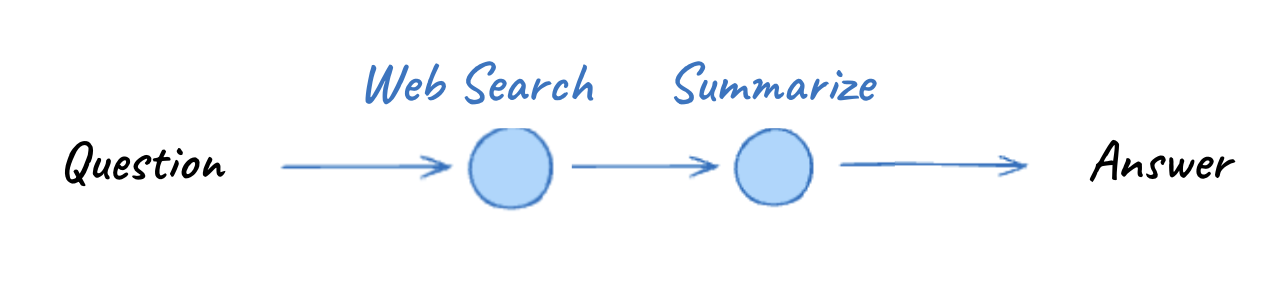

In this notebook, we're going to walk through setting up a simple chatbot in LangGraph.

Let's start by loading our environment variables from our .env file.

In [1]:
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env", override=True)
# Loads the following env variables
# LANGSMITH_TRACING=true
# LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
# LANGSMITH_PROJECT="eli5-bot"
# LANGSMITH_API_KEY="<redacted>"

# OPENAI_API_KEY="<redacted>"
# TAVILY_API_KEY="<redacted>"

True

## Setup

Let's set up a tool called Tavily to allow our assistant to search the web when answering

In [2]:
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results=1)

Let's design a prompt for RAG that we'll use throughout the notebook.

In [15]:
prompt = """You are a professor and expert in explaining complex topics in a way that is easy to understand.
Your job is to answer the provided question so that even a 5 year old can understand it.
You have provided with relevant background context to answer the question.

Context: {context}

Answer:"""
print("Prompt Template: ", prompt)

Prompt Template:  You are a professor and expert in explaining complex topics in a way that is easy to understand.
Your job is to answer the provided question so that even a 5 year old can understand it.
You have provided with relevant background context to answer the question.

Context: {context}

Answer:


## Creating Our Application

In [16]:
from openai import OpenAI
from langsmith import traceable
from langsmith.wrappers import wrap_openai

openai_client = wrap_openai(OpenAI())

@traceable
def search(question):
    web_docs = web_search_tool.invoke({"query": question})
    results = web_docs.get("results", [])
    web_results = "\n".join([r["content"] for r in results])
    return web_results

@traceable
def explain(question, context):
    formatted = prompt.format(context=context)
    completion = openai_client.chat.completions.create(
        messages=[
            {"role": "system", "content": formatted},
            {"role": "user", "content": question},
        ],
        model="gpt-4o-mini",
    )
    return completion.choices[0].message.content

@traceable(name="Q&A Pipeline")
def qa(question):
    context = search(question)
    answer = explain(question, context)
    return answer

## Testing Our Application

In [17]:
question = "What is LangChain?"
print(qa(question))

LangChain is like a big toolbox that helps people who make computer programs to use smart language skills. Imagine you have a toy that can talk to you and understand what you say. LangChain helps programmers build and make that toy even better by connecting it to other special places where it can find more information, like books or databases. 

So, if a programmer wants their toy to answer questions or tell stories, LangChain gives them all the tools they need to make that happen easily. It's like having a magic guide that shows you how to put together pieces to make something really cool!


## Application Using LangGraph

Let's define the State for our Graph. We'll track the user's question, our application's generation, and the list of relevant documents.

In [18]:
from langchain_core.documents import Document
from typing import List
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    """
    question: str
    documents: List[str]
    messages: List[str]


Great, now let's define the nodes of our graph

In [22]:
from langchain_core.messages import HumanMessage


def search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    question = state["question"]
    documents = state.get("documents", [])

    # Web search
    web_docs = web_search_tool.invoke({"query": question})
    results = web_docs.get("results", [])
    web_results = "\n".join(r.get("content", "") for r in results)

    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}


def explain(state: GraphState):
    """
    Generate response
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    question = state["question"]
    documents = state.get("documents", [])
    formatted = prompt.format(context="\n".join([d.page_content for d in documents]))
    generation = llm.invoke([HumanMessage(content=formatted)])
    return {"question": question, "messages": [generation]}

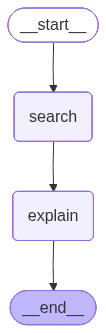

In [23]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(GraphState)
graph.add_node("explain", explain)
graph.add_node("search", search)
graph.add_edge(START, "search")
graph.add_edge("search", "explain")
graph.add_edge("explain", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

## Testing Our Graph

Let's create a helper function to pretty print our results

In [24]:
def ask(question: str):
    for output in app.stream({"question": question}, stream_mode="updates"):
        if END in output or START in output:
            continue
        # Print any node outputs
        for key, value in output.items():
            if "messages" in value:
                print(value["messages"][0].content)


Finally, let's test our chatbot out and see how it works!

In [25]:
question = "What is complexity economics?"
ask(question)

Imagine you have a big box of colorful building blocks. Each block is a different shape and color, and you can put them together in lots of different ways to make all sorts of things, like a castle or a spaceship. Now, think of each block as a tiny part of the economy, like a person buying a toy or a store selling candy.

Complexity economics is like playing with these blocks. It looks at how all these little actions, like buying and selling, can come together to create big things, like how many toys are sold in a whole country. Sometimes, when you put the blocks together in a certain way, you might get a surprise, like a really cool tower you didn't expect. That's what happens in the economy too—small actions can lead to big, surprising results.

Even though these surprises can happen, people who study complexity economics often find that the big picture matches what they already know about how the economy works. It's like when you build with blocks and end up with a castle that looks

Output in LangSmith

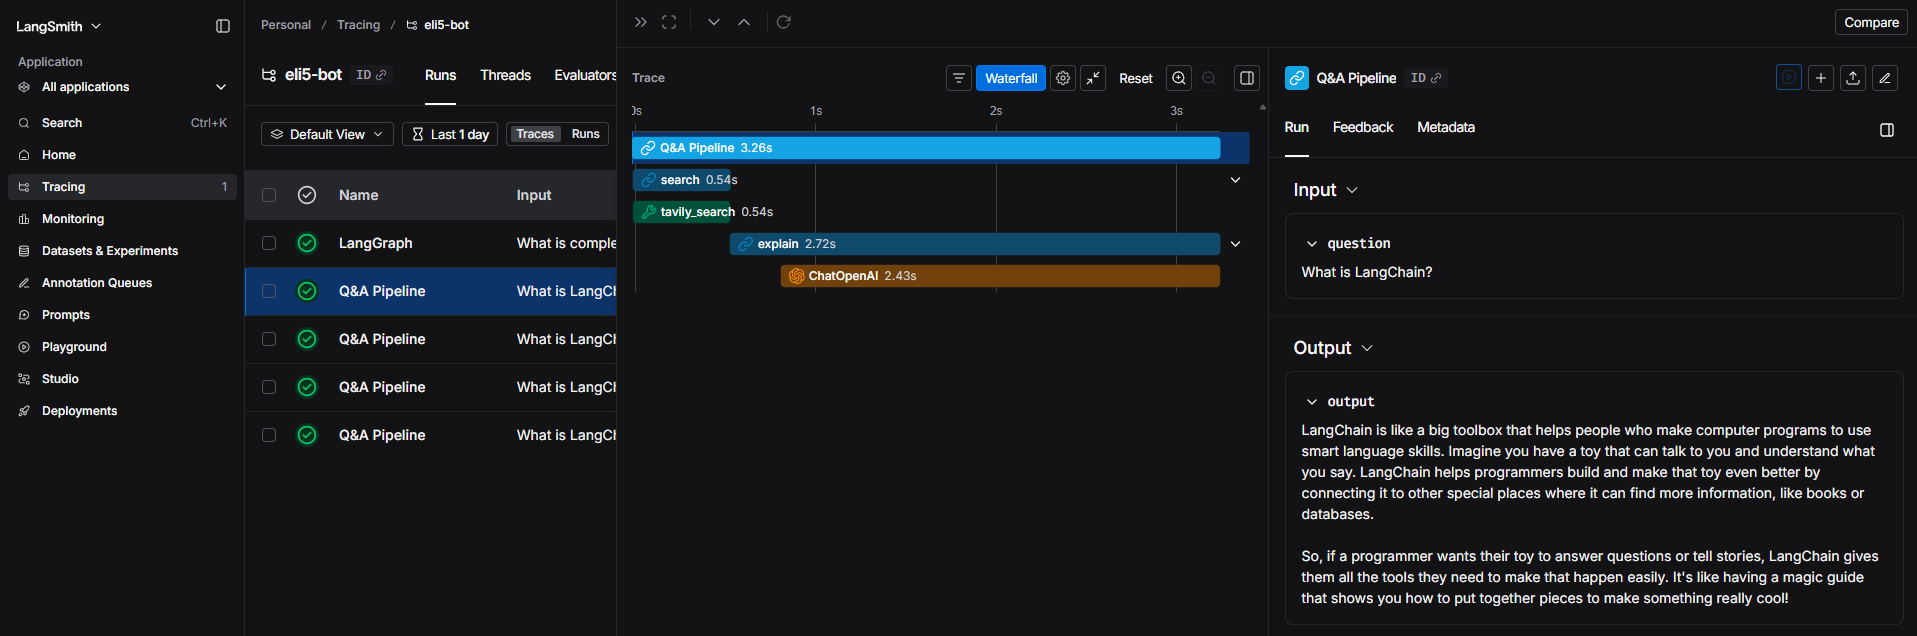